# Modeling KBest - Decision Tree - Hugo Fiévet

## Table of Contents

1. [Objective](#1-objective)
2. [Baseline Model](#2-baseline-model)
3. [Hyperparameter Tuning](#3-hyperparameter-tuning)
4. [Final Evaluation](#4-final-evaluation)
5. [Model Limits](#5-model-limits)


## 1. Objective

Établir une performance de référence du modèle avec ses paramètres par défaut avant optimisation des hyperparamètres.

## 2. Baseline Model

In [7]:
import pandas as pd
from sklearn.tree import DecisionTreeClassifier 
from sklearn.model_selection import cross_validate,StratifiedKFold,GridSearchCV
from sklearn.metrics import  accuracy_score,precision_score,recall_score,f1_score,classification_report,confusion_matrix

RANDOM_STATE = 42

dt =  DecisionTreeClassifier(random_state=RANDOM_STATE)



xtrain_KB = pd.read_csv("xtrain_KB.csv")
ytrain = pd.read_csv("ytrain.csv").squeeze("columns")

StratifiedKfold_cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE,
)

cv_results = cross_validate(estimator=dt,X=xtrain_KB,y=ytrain,scoring="f1_macro",return_train_score=True,cv=StratifiedKfold_cv)
pd.DataFrame(cv_results)


,fit_time,score_time,test_score,train_score
0,0.153045,0.018477,0.654119,1.0
1,0.163206,0.022471,0.647087,1.0
2,0.127030,0.034063,0.636016,1.0
3,0.184466,0.013421,0.663470,1.0
4,0.108640,0.048934,0.649571,1.0


In [8]:
print("Mean train score : ",cv_results["train_score"].mean())
print("Mean validation score",cv_results["test_score"].mean())

Mean train score :  1.0
Mean validation score 0.650052532200914


Le Decision Tree avec ses paramètres par défaut obtient un F1-macro moyen d’environ **0,650** en validation croisée. Les scores de validation varient entre environ **0,636 et 0,663**, ce qui montre une variabilité limitée entre les folds.

Le F1-macro moyen d’entraînement est de **1,000**. L’écart entraînement–validation est donc d’environ **0,350**, ce qui met en évidence un surapprentissage important.

Cette baseline confirme que l’arbre est trop complexe dans sa configuration par défaut. L’optimisation doit donc régulariser le modèle afin de réduire cet écart et d’améliorer sa capacité de généralisation.

## 3. Hyperparameter Tuning

In [9]:
settings_grid = {
    "max_depth":[None,10,20],
    "min_samples_leaf":[1, 2, 5],
    "max_features":["sqrt", 0.5],
}

grid_search =  GridSearchCV(estimator=dt,param_grid=settings_grid,scoring="f1_macro",cv=StratifiedKfold_cv,return_train_score=True)


grid_search.fit(
    X=xtrain_KB,
    y=ytrain
)


,estimator,DecisionTreeC...ndom_state=42)
,param_grid,"{'max_depth': [None, 10, ...], 'max_features': ['sqrt', 0.5], 'min_samples_leaf': [1, 2, ...]}"
,scoring,'f1_macro'
,n_jobs,None
,refit,True
,cv,StratifiedKFo... shuffle=True)
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,True
,criterion,'gini'


In [10]:
best_index = grid_search.best_index_

print("Best parameters:", grid_search.best_params_)

print("Best validation F1:", grid_search.best_score_)
print(
    "Mean train F1:",
    grid_search.cv_results_["mean_train_score"][best_index]
)
print(
    "Std validation F1:",
    grid_search.cv_results_["std_test_score"][best_index]
)

Best parameters: {'max_depth': 10, 'max_features': 0.5, 'min_samples_leaf': 5}
Best validation F1: 0.6916281953118362
Mean train F1: 0.7872413693504051
Std validation F1: 0.008343332844804478


Après optimisation, les hyperparamètres retenus sont `max_depth=10`, `max_features=0.5` et `min_samples_leaf=5`.

Le F1-macro moyen de validation atteint **0,692**, contre environ **0,650** pour la baseline. Le F1-macro moyen d’entraînement diminue à **0,787**.

L’écart entraînement–validation passe ainsi d’environ **0,350 à 0,096**. La régularisation réduit donc nettement le surapprentissage tout en améliorant la performance de validation.

L’écart-type du F1-macro de validation est d’environ **0,008**, ce qui indique une dispersion limitée entre les cinq folds.

## 4. Final Evaluation

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt
X_test_KB = pd.read_csv("xtest_KB.csv")
y_test = pd.read_csv("ytest.csv").squeeze("columns")

best_model = grid_search.best_estimator_

y_pred = best_model.predict(X=X_test_KB)

class_report = classification_report(y_test, y_pred)
accuracy  = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average="macro")
recall = recall_score(y_test, y_pred, average="macro")
f1 = f1_score(y_test, y_pred, average="macro")

print("Accuracy :",accuracy )
print("Precision macro :",precision )
print("Recall macro :",recall )
print("F1 macro :", f1)

Accuracy : 0.7292211186617877
Precision macro : 0.6970298817570136
Recall macro : 0.7005571499297357
F1 macro : 0.6984825070478525


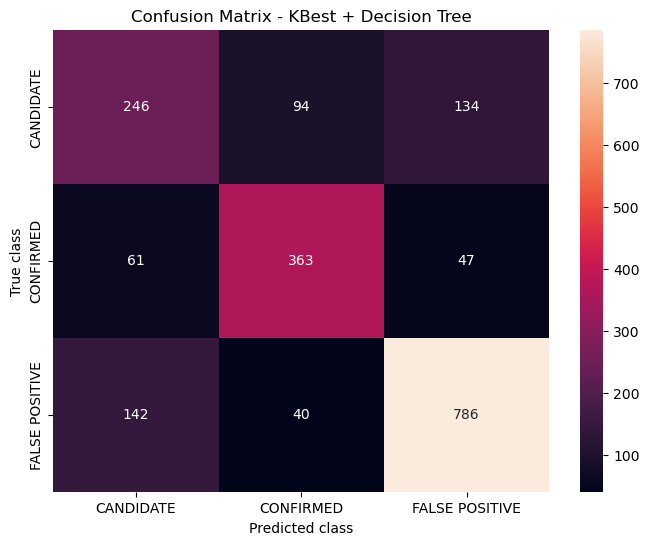

In [12]:
labels = ["CANDIDATE", "CONFIRMED", "FALSE POSITIVE"]

cm = confusion_matrix(
    y_test,
    y_pred,
    labels=labels
)

plt.figure(figsize=(8, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=labels,
    yticklabels=labels,
)

plt.xlabel("Predicted class")
plt.ylabel("True class")
plt.title("Confusion Matrix - KBest + Decision Tree")

plt.show()

Sur le jeu de test actuel de **1 913 observations**, le Decision Tree optimisé obtient :

- **Accuracy : 0,7292**
- **Precision macro : 0,6970**
- **Recall macro : 0,7006**
- **F1 macro : 0,6985**

La matrice de confusion confirme que la classe `CANDIDATE` reste la plus difficile à identifier : **246 observations sur 474** sont correctement classées (rappel ≈ **0,519**).

Le modèle reconnaît mieux les deux autres classes : **363 `CONFIRMED` sur 471** sont correctement prédits (rappel ≈ **0,771**) et **786 `FALSE POSITIVE` sur 968** sont correctement identifiés (rappel ≈ **0,812**).

Le résultat final reste donc cohérent avec l’analyse précédente : les objets `CANDIDATE` présentent davantage de chevauchement avec les deux autres classes, ce qui pénalise le F1-macro global.

## 5. Model Limits

C’est assez cohérent avec la nature même d’un **candidat KOI** : il s’agit précisément d’un objet dont le statut n’est pas encore suffisamment établi pour être confirmé ou rejeté. Donc il est intéressant de se demander si une partie de la difficulté du Machine Learning vient non seulement du modèle, mais aussi de l’ambiguïté intrinsèque de la cible `CANDIDATE`.